### Thierry (Assister par IA)
## Carte de clustering

In [23]:
# Installation des dépendances (à exécuter une seule fois)
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn folium scikit-learn joblib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports et configuration

Import des bibliothèques nécessaires :
- `pandas` / `numpy` : manipulation des données
- `scikit-learn` : algorithme `KMeans` et métriques d'évaluation du clustering
- `folium` : cartes interactives (OpenStreetMap)
- `joblib` : sérialisation du modèle entraîné
- `matplotlib` / `seaborn` : visualisations statiques
- `os` : gestion des fichiers

In [24]:
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
import folium
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("output", exist_ok=True)

## Chargement des données

Lecture du fichier CSV exporté depuis le registre national des bornes de recharge (IRVE).
Le dataset contient ~138 000 points de charge avec 47 colonnes (opérateur, localisation, puissance, horaires, etc.).

In [25]:
# Chargement des données IRVE
irve = pd.read_csv("export_IA.csv")

irve.head()

C:\Users\dacks\AppData\Local\Temp\ipykernel_103384\2245108606.py:2: DtypeWarning: Columns (0: code_insee, 1: prise_ef, 2: prise_type2, 3: prise_ccs, 4: prise_chademo, 5: prise_autre, 6: deux_roues, 7: paiement_acte, 8: paiement_cb, 9: reservation) have mixed types. Specify dtype option on import or set low_memory=False.
  irve = pd.read_csv("export_IA.csv")


,id_pdc,id_station,id_station_local,id_pdc_local,nom_station,nom_amenageur,siren_amenageur,contact_amenageur,operateur,contact_operateur,...,gratuit,paiement_acte,paiement_cb,paiement_autre,tarification_brute,condition_acces,reservation,horaires,date_service,date_maj
0,DKMONE3785539,DKMONE3785539,NaN,NaN,Golf de Garonne,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,Mo-Su 08:00-19:00,2024-10-24,2024-10-23
1,DKMONE3785590,DKMONE3785539,NaN,NaN,Golf de Garonne,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,Mo-Su 08:00-19:00,2024-10-24,2024-10-23
2,DKMONE3785709,DKMONE3785709,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,True,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30
3,DKMONE3785711,DKMONE3785711,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,True,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30
4,DKMONE3785713,DKMONE3785713,NaN,NaN,Montestruc,SOLVEO ENERGIES,508886132.0,bornes@solveo-energies.com,SOLVEO ENERGIES,bornes@solveo-energies.com,...,False,True,False,False,NaN,Accès libre,False,24/7,2024-11-28,2025-01-30


## Apprentissage non-supervisé

**Variables retenues :** `latitude`, `longitude`.

**Justification du choix des variables :**
- Seules `latitude` / `longitude` sont utilisées : le besoin est une sectorisation purement géographique des bornes, sans tenir compte de leurs autres caractéristiques (puissance, opérateur, type d'implantation…).
- `dropna` est appliqué sur ces deux colonnes uniquement — une borne sans coordonnées ne peut pas être positionnée sur la carte ni assignée à un cluster.

**Algorithme choisi : K-Means**

**Principe de fonctionnement :**
1. On fixe à l'avance un nombre de clusters K et on place K centroïdes initiaux (ici aléatoirement, répété `n_init=10` fois pour éviter un mauvais tirage).
2. Chaque borne est assignée au centroïde le plus proche (distance euclidienne sur latitude/longitude).
3. Chaque centroïde est recalculé comme la moyenne des bornes qui lui sont assignées.
4. Les étapes 2 et 3 sont répétées jusqu'à convergence (les assignations ne changent plus), c'est-à-dire jusqu'à minimiser l'inertie (somme des distances au carré entre chaque borne et son centroïde).

**Justification du choix de K-Means face aux alternatives (cf. [scikit-learn clustering](https://scikit-learn.org/stable/modules/clustering.html)) :**
- **K-Means** : rapide même sur ~139 000 points, produit des zones compactes et de taille comparable — adapté à une sectorisation opérationnelle où chaque cluster doit représenter une zone géographique exploitable.
- **DBSCAN** (écarté) : adapté aux clusters de densité variable et à la détection de bruit, mais les bornes IRVE sont denses en zone urbaine et très clairsemées en zone rurale — DBSCAN regrouperait l'essentiel des points en un unique cluster urbain géant, peu utile pour une sectorisation équilibrée.
- **Clustering hiérarchique** (écarté) : complexité au moins quadratique en nombre de points, inutilisable en pratique sur ~139 000 bornes.

In [26]:
# Extraction de la longitude et latitude
irve = irve.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
X = irve[["latitude", "longitude"]]

## Recherche de nombre de cluster

**Justification du choix des métriques :**
- **Silhouette Score** : mesure la cohésion intra-cluster vs la séparation inter-cluster, idéal le plus HAUT. Calculé sur un échantillon de 5000 points (`sample_size=5000`) pour rester rapide malgré les ~139 000 bornes.
- **Calinski-Harabasz** : ratio de dispersion inter/intra-cluster, idéal le plus HAUT. Sensible aux clusters bien séparés, complémentaire au Silhouette.
- **Davies-Bouldin** : mesure la similarité moyenne entre clusters voisins, idéal le plus BAS. Permet de détecter des clusters trop proches les uns des autres.

Les valeurs de K testées (2, 3, 4, 5, 6, 7, 12) couvrent une plage large pour situer visuellement où se trouve le meilleur compromis avant de restreindre le choix final à 5, 6 ou 7 (cf. section suivante).

In [27]:
results = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 12]

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # Calcul des métriques demandées
    sil = silhouette_score(X, cluster_labels, sample_size=5000, random_state=42)
    ch = calinski_harabasz_score(X, cluster_labels)
    db = davies_bouldin_score(X, cluster_labels)

    results.append(
        {
            "K": k,
            "Silhouette": sil,
            "Calinski-Harabasz": ch,
            "Davies-Bouldin": db,
            "Inertie": kmeans.inertia_,
        }
    )

## Affichage du tableau comparatif pour votre rapport


--- TABLEAU DES MÉTRIQUES D'ÉVALUATION ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin       Inertie
 2    0.429095      110941.820298        0.984881 969901.556246
 3    0.473423      137524.361620        0.742466 585420.443121
 4    0.483410      143551.465010        0.706245 425485.333066
 5    0.511239      174391.514330        0.694862 289718.575592
 6    0.500574      171598.553677        0.745013 243095.615226
 7    0.513699      176903.630090        0.730877 201894.900815
12    0.494585      191933.284649        0.704414 107699.412461
------------------------------------------


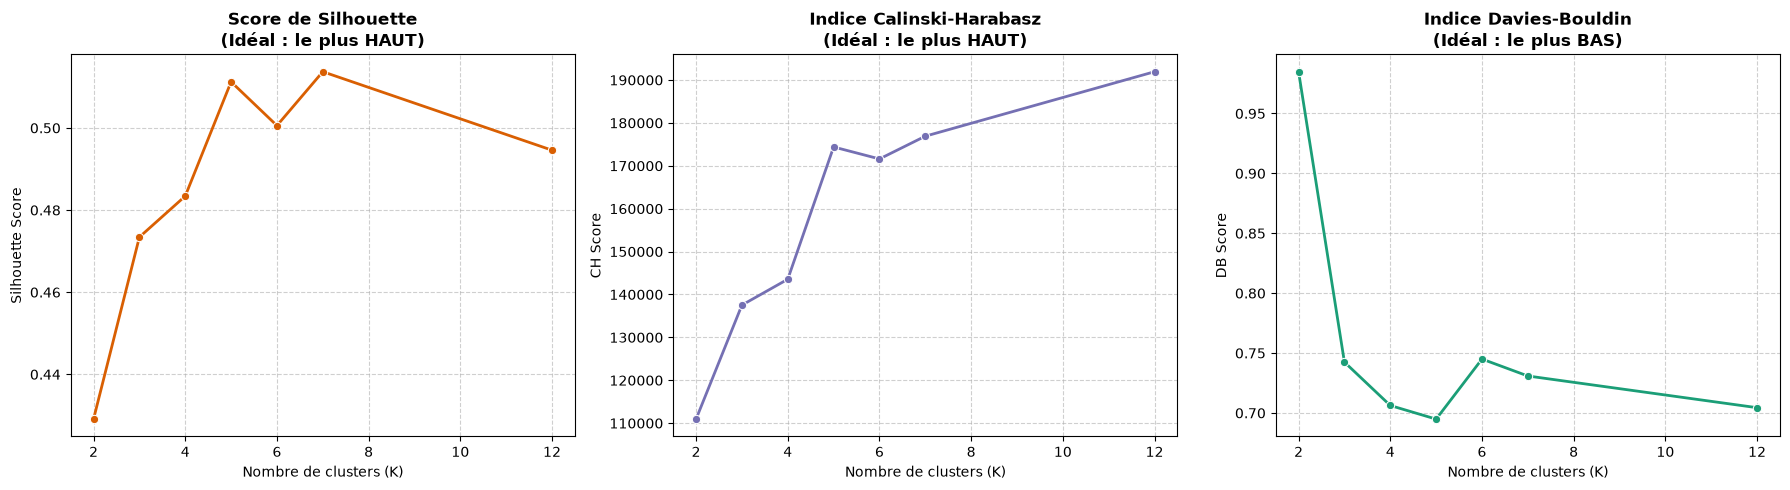

In [28]:
# Affichage du tableau comparatif pour votre rapport
df_metrics = pd.DataFrame(results)
print("\n--- TABLEAU DES MÉTRIQUES D'ÉVALUATION ---")
print(df_metrics.to_string(index=False))
print("------------------------------------------")
# 2. Configuration de l'affichage (1 ligne, 3 graphiques)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Score de Silhouette
sns.lineplot(ax=axes[0], data=df_metrics, x='K', y='Silhouette', marker='o', linewidth=2, color='#d95f02')
axes[0].set_title("Score de Silhouette\n(Idéal : le plus HAUT)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Graphique 2 : Indice Calinski-Harabasz
sns.lineplot(ax=axes[1], data=df_metrics, x='K', y='Calinski-Harabasz', marker='o', linewidth=2, color='#7570b3')
axes[1].set_title("Indice Calinski-Harabasz\n(Idéal : le plus HAUT)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("CH Score")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Graphique 3 : Indice Davies-Bouldin
sns.lineplot(ax=axes[2], data=df_metrics, x='K', y='Davies-Bouldin', marker='o', linewidth=2, color='#1b9e77')
axes[2].set_title("Indice Davies-Bouldin\n(Idéal : le plus BAS)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Nombre de clusters (K)")
axes[2].set_ylabel("DB Score")
axes[2].grid(True, linestyle='--', alpha=0.6)

# Ajustement automatique des espaces et affichage
plt.tight_layout()
plt.savefig(os.path.join("output", "metriques_clustering.png"))
plt.show()

## Méthode du coude (elbow) — complément pour le choix de K

Visualisation classique pour K-Means : la courbe d'inertie (somme des distances au carré entre chaque borne et son centroïde) décroît toujours avec K, mais le "coude" indique où ajouter un cluster supplémentaire n'apporte plus de gain significatif. Complète les métriques Silhouette/Calinski-Harabasz/Davies-Bouldin déjà calculées.

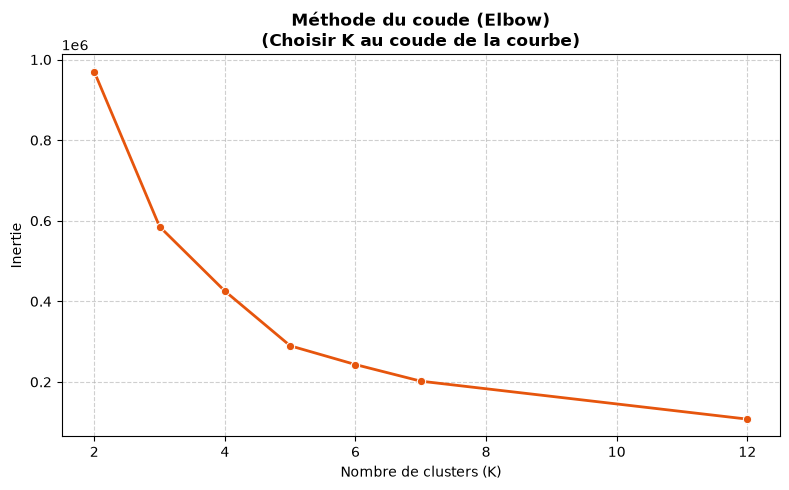

In [29]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_metrics, x='K', y='Inertie', marker='o', linewidth=2, color='#e6550d')
plt.title("Méthode du coude (Elbow)\n(Choisir K au coude de la courbe)", fontsize=12, fontweight='bold')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join("output", "elbow_inertie.png"))
plt.show()

## Discussion des résultats

**Lecture du tableau et des graphes :**
- Le **Silhouette Score** progresse de K=2 (~0,43) à K=7 (~0,51), avec un léger creux à K=6. Les valeurs 5 et 7 sont quasiment à égalité et constituent les meilleurs scores observés sur toute la plage testée.
- L'indice **Calinski-Harabasz** augmente quasi continûment avec K (de ~111 000 à K=2 jusqu'à ~192 000 à K=12) : cet indice favorise structurellement un grand nombre de petits clusters bien séparés, il n'est donc pas décisif seul pour choisir entre 5, 6 et 7 — il confirme surtout que K=7 reste préférable à K=5/6 sur ce critère précis.
- L'indice **Davies-Bouldin** (plus bas = mieux) est minimal à K=5 (~0,69), légèrement plus élevé à K=6 (~0,75) et K=7 (~0,73) : K=5 produit les clusters les moins chevauchants.
- La courbe d'**inertie** (elbow) chute fortement entre K=2 et K=5, puis ralentit nettement : au-delà de K≈5, chaque cluster supplémentaire réduit beaucoup moins l'inertie, ce qui situe le coude autour de K=5.

**Conclusion :** aucune métrique n'est unanime, mais K=5 obtient le meilleur Davies-Bouldin et un Silhouette proche du maximum, tout en correspondant au coude de la courbe d'inertie — c'est le choix par défaut (`k_choisi`). K=7 reste une alternative valable si l'on privilégie le Silhouette/Calinski-Harabasz au prix de clusters un peu plus chevauchants ; K=6 n'apporte d'avantage sur aucune métrique et n'est conservé que pour rester flexible avec le besoin client (5, 6 ou 7).

## Choix du nombre de clusters et entraînement du modèle final

**Justification du choix de K :**
- Le besoin client impose de restreindre le choix à 5, 6 ou 7 clusters — un compromis entre une sectorisation trop grossière (moins de 5 zones) et trop fragmentée (plus de 7 zones) pour rester opérationnelle.
- Conformément à la discussion ci-dessus, un modèle est entraîné et sauvegardé pour **chacune** des trois valeurs (5, 6 et 7), afin que `main.py` puisse charger directement le modèle correspondant au `--k` demandé **sans jamais relancer un entraînement** à l'exécution.
- `k_choisi` ci-dessous désigne le modèle utilisé par défaut (`kmeans_irve_model.pkl`) pour la carte générée plus bas dans ce notebook.

In [30]:
# Modèle utilisé par défaut pour la carte de ce notebook : modifier cette valeur (5, 6 ou 7)
k_choisi = 5

if k_choisi not in (5, 6, 7):
    raise ValueError("k_choisi doit être 5, 6 ou 7.")

# Entraînement et sauvegarde d'un modèle par valeur de K (5, 6, 7) : main.py
# n'a ainsi jamais besoin de réentraîner, il lui suffit de charger le fichier
# correspondant au K demandé.
modeles_entraines = {}
for k in (5, 6, 7):
    print(f"Entraînement du modèle KMeans avec K={k}...")
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_k.fit(X)
    modeles_entraines[k] = kmeans_k

    nom_fichier = f"kmeans_irve_model_k{k}.pkl"
    joblib.dump(kmeans_k, nom_fichier)
    print(f"  -> sauvegardé sous '{nom_fichier}'")

# Modèle par défaut (utilisé par la carte de ce notebook et par main.py
# quand --k n'est pas fourni)
final_kmeans = modeles_entraines[k_choisi]
model_filename = "kmeans_irve_model.pkl"
joblib.dump(final_kmeans, model_filename)
print(f"\nModèle par défaut (K={k_choisi}) sauvegardé sous '{model_filename}'")

Entraînement du modèle KMeans avec K=5...
  -> sauvegardé sous 'kmeans_irve_model_k5.pkl'
Entraînement du modèle KMeans avec K=6...
  -> sauvegardé sous 'kmeans_irve_model_k6.pkl'
Entraînement du modèle KMeans avec K=7...
  -> sauvegardé sous 'kmeans_irve_model_k7.pkl'

Modèle par défaut (K=5) sauvegardé sous 'kmeans_irve_model.pkl'


## Creation de la carte de clustering

**Justification du choix de Folium + FeatureGroup (sans MarkerCluster) :**
- **Folium** : bibliothèque Python légère basée sur Leaflet.js. Produit des cartes HTML interactives sans serveur — idéal pour partager des résultats en standalone.
- **CartoDB Positron** : tuiles utilisées à la place d'OpenStreetMap pour éviter les erreurs réseau (403 Forbidden) et offrir une meilleure lisibilité des clusters.
- **FeatureGroup par cluster, sans `MarkerCluster`** : contrairement à la carte du Besoin Client 1, l'objectif ici n'est pas de regrouper visuellement les bornes proches mais de garder une couleur distincte et lisible pour chaque cluster K-Means. Un `MarkerCluster` mélangerait les couleurs et masquerait les frontières entre clusters.

La carte est centrée sur la moyenne des positions des bornes. Un contrôle de couches permet d'afficher/masquer chaque cluster indépendamment.

In [31]:
# Rechargement du modèle préalablement enregistré
final_kmeans = joblib.load("kmeans_irve_model.pkl")

# Assignation des clusters aux données existantes
X = irve[["latitude", "longitude"]]
irve["cluster"] = final_kmeans.predict(X)

# Création de la carte centrée sur la moyenne des positions
map_center = [irve["latitude"].mean(), irve["longitude"].mean()]
carte = folium.Map(location=map_center, zoom_start=6, tiles="CartoDB positron", prefer_canvas=True)

# Palette de couleurs pour différencier les clusters
colors = ["red", "blue", "green", "purple", "orange", "darkred", "cadetblue"]

# Un FeatureGroup par cluster (sans MarkerCluster) : chaque borne garde sa
# couleur de cluster visible individuellement, contrairement à un
# regroupement par proximité géographique (qui mélangerait les couleurs et
# masquerait les frontières entre clusters).
cluster_groups = {}
for cluster_id in sorted(irve["cluster"].unique()):
    cluster_groups[cluster_id] = folium.FeatureGroup(name=f"Cluster {cluster_id}").add_to(carte)

for idx, row in irve.iterrows():
    cluster_id = int(row["cluster"])
    color = colors[cluster_id % len(colors)]

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"Borne ID: {idx}<br>Cluster: {cluster_id}",
    ).add_to(cluster_groups[cluster_id])

folium.LayerControl(collapsed=False).add_to(carte)

In [32]:
chemin_carte = os.path.join("output", "carte_clusters_irve.html")
carte.save(chemin_carte)
print(
    f"La carte interactive a été générée sous le nom '{chemin_carte}'. Ouvrez-la dans un navigateur !"
)

La carte interactive a été générée sous le nom 'output\carte_clusters_irve.html'. Ouvrez-la dans un navigateur !


## Répartition des bornes par cluster

Complète la discussion des métriques : permet de vérifier si les clusters obtenus avec `k_choisi` sont équilibrés en nombre de bornes ou si certains dominent largement les autres (ce qui questionnerait la pertinence opérationnelle de la sectorisation).

Nombre de bornes par cluster :
cluster
0    23093
1    14793
2    47354
3    33408
4    20286
Name: count, dtype: int64


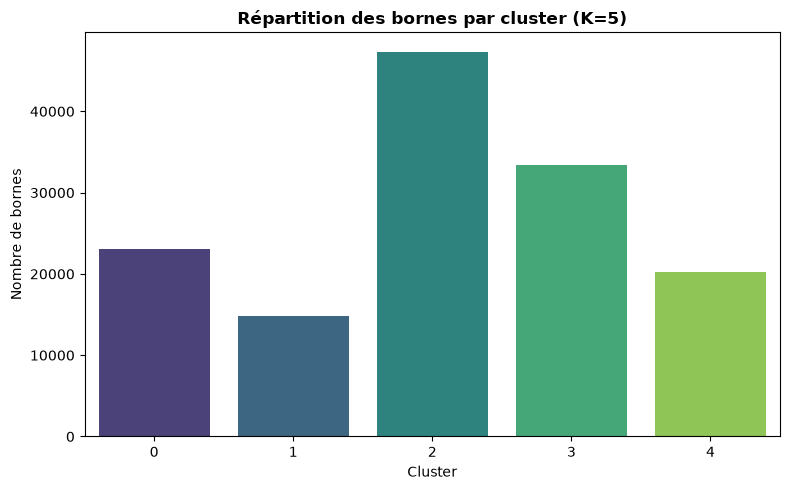

In [33]:
repartition = irve["cluster"].value_counts().sort_index()
print("Nombre de bornes par cluster :")
print(repartition)

plt.figure(figsize=(8, 5))
sns.barplot(x=repartition.index.astype(str), y=repartition.values, hue=repartition.index.astype(str), legend=False, palette="viridis")
plt.title(f"Répartition des bornes par cluster (K={k_choisi})", fontsize=12, fontweight='bold')
plt.xlabel("Cluster")
plt.ylabel("Nombre de bornes")
plt.tight_layout()
plt.savefig(os.path.join("output", "repartition_clusters.png"))
plt.show()